# Task 3: Constrastive Learning and CLIP

##1 Subtask 1: Zero-Shot Classification on STL-10

In this subtask, we evaluate a pretrained CLIP model on the complete STL-10 test set using zero-shot classification

We compare 3 prompting strategies:
    1. Plain Class Labels
    2. "A photo of a ..." prompts
    3. More descriptive type class-specific complex prompts


In [1]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00


In [2]:
import random

import numpy as np
import pandas as pd

import torch

from torch.utils.data import DataLoader
from torchvision.datasets import STL10

import matplotlib.pyplot as plot

from tqdm.auto import tqdm

import clip

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name())

Device:  cpu


In [4]:
model, preprocess = clip.load("ViT-B/32", device= device)

model.eval()

print("CLIP model loaded successfully")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 200MiB/s]


CLIP model loaded successfully


In [5]:
test_dataset = STL10(
    root = "./data",
    split= "test",
    download= True,
    transform= preprocess
)

print("Number of Test Images: ", len(test_dataset))
print("Classes: ", test_dataset.classes)

class_names = test_dataset.classes
print("Number of classes:", len(class_names))

for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

100%|██████████| 2.64G/2.64G [07:19<00:00, 6.01MB/s]


Number of Test Images:  8000
Classes:  ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number of classes: 10
0 -> airplane
1 -> bird
2 -> car
3 -> cat
4 -> deer
5 -> dog
6 -> horse
7 -> monkey
8 -> ship
9 -> truck


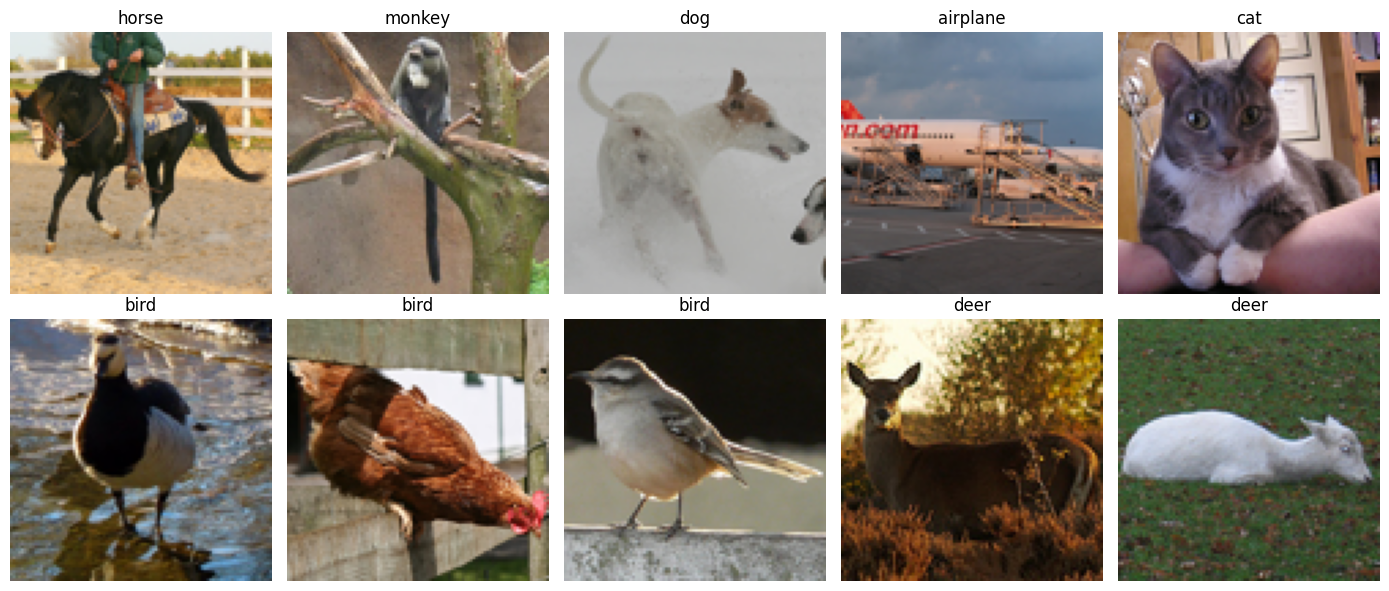

In [6]:
figure, axes = plot.subplots(2,5, figsize = (14,6))

axes = axes.flatten()

for index in range(10):
    image =  test_dataset.data[index]
    label = test_dataset.labels[index]

    image = np.transpose(image, (1,2, 0))

    axes[index].imshow(image)
    axes[index].set_title(class_names[label])
    axes[index].axis("off")

plot.tight_layout()
plot.show()

In [7]:
BATCH_SIZE = 128 if torch.cuda.is_available() else 32

test_loader = DataLoader(test_dataset, batch_size= BATCH_SIZE, shuffle= False, num_workers= 0, pin_memory  = torch.cuda.is_available())

print("Batch Size: ", BATCH_SIZE)
print("Number of batches:", len(test_loader))

all_image_features = []
all_labels = []

with torch.inference_mode():

    for images, labels in tqdm(test_loader, desc = "Encoding STL-10 images"):
        images = images.to(device)

        image_features = model.encode_image(images)
        image_features = (image_features / image_features.norm(dim  = 1, keepdim = True))

        all_image_features.append(image_features.float().cpu())
        all_labels.append(labels)

all_image_features = torch.cat(all_image_features, dim = 0)
all_labels = torch.cat(all_labels, dim= 0)

print("Image Feature shape: ", all_image_features.shape)
print("Label shape: ", all_labels.shape)

Batch Size:  32
Number of batches: 250


Encoding STL-10 images:   0%|          | 0/250 [00:00<?, ?it/s]

Image Feature shape:  torch.Size([8000, 512])
Label shape:  torch.Size([8000])


In [8]:
assert all_image_features.shape[0] == len(test_dataset)
assert all_labels.shape[0] == len(test_dataset)

print("Successfully encoded all ", len(test_dataset), "STL-10 test images")

Successfully encoded all  8000 STL-10 test images


In [9]:
plain_prompts = class_names

photo_prompts = [f"a photo of a {class_name}" for class_name in class_names]

descriptive_prompts = [
                        "a photo of an airplane, a flying vehicle with wings",
                        "a photo of a bird, an animal with feathers and wings",
                        "a photo of a car, a road vehicle with four wheels",
                        "a photo of a cat, a small domestic feline animal",
                        "a photo of a deer, a wild four-legged animal with slender legs",
                        "a photo of a dog, a domestic canine animal",
                        "a photo of a horse, a large four-legged animal commonly ridden by people",
                        "a photo of a monkey, a primate animal often seen climbing",
                        "a photo of a ship, a large vessel traveling on water",
                        "a photo of a truck, a large road vehicle used for carrying goods"
                       ]

prompt_strategies = {
                        "Plain Labels" : plain_prompts,
                        "Photo prompt" : photo_prompts,
                        "Descriptive prompt" : descriptive_prompts
                    }

In [10]:
for strategy_name, prompts in prompt_strategies.items():

    print("\n", strategy_name)
    print("-" * 50)

    for class_name, prompt in zip(class_names, prompts):
        print(f"{class_name:10s} -> {prompt}")


 Plain Labels
--------------------------------------------------
airplane   -> airplane
bird       -> bird
car        -> car
cat        -> cat
deer       -> deer
dog        -> dog
horse      -> horse
monkey     -> monkey
ship       -> ship
truck      -> truck

 Photo prompt
--------------------------------------------------
airplane   -> a photo of a airplane
bird       -> a photo of a bird
car        -> a photo of a car
cat        -> a photo of a cat
deer       -> a photo of a deer
dog        -> a photo of a dog
horse      -> a photo of a horse
monkey     -> a photo of a monkey
ship       -> a photo of a ship
truck      -> a photo of a truck

 Descriptive prompt
--------------------------------------------------
airplane   -> a photo of an airplane, a flying vehicle with wings
bird       -> a photo of a bird, an animal with feathers and wings
car        -> a photo of a car, a road vehicle with four wheels
cat        -> a photo of a cat, a small domestic feline animal
deer       -> a 

In [11]:
def encode_text_prompts(prompts):

    text_tokens = clip.tokenize(prompts).to(device)

    with torch.inference_mode():
        test_features = model.encode_text(text_tokens)

        test_features = test_features / test_features.norm(dim = -1, keepdim = True)

    return test_features.float().cpu()

In [12]:
def calculate_zero_shot_accuracy(image_features, labels, text_features):

    cosine_similarities = image_features @ text_features.T

    predictions = cosine_similarities.argmax(dim = 1)

    accuracy = (predictions == labels).float().mean().item() * 100

    return accuracy, predictions

In [13]:
results = {}
text_features_by_strategy = {}
predictions_by_strategy = {}

for strat_name, prompts in prompt_strategies.items():
    text_features = encode_text_prompts(prompts)

    accuracy, predictions = calculate_zero_shot_accuracy(all_image_features, all_labels, text_features)

    results[strat_name] = accuracy

    text_features_by_strategy[strat_name] = text_features

    predictions_by_strategy[strat_name] = predictions

    print(f"{strat_name}: " f"{accuracy:.2f}%")

Plain Labels: 96.25%
Photo prompt: 97.36%
Descriptive prompt: 94.96%


In [14]:
result_table = pd.DataFrame({
                                "Prompt Strategy" : list(results.keys()),
                                "Accuracy (%)" : list(results.values())
                            })

result_table = result_table.sort_values(by= "Accuracy (%)", ascending = False)

result_table

,Prompt Strategy,Accuracy (%)
1,Photo prompt,97.362500
0,Plain Labels,96.249998
2,Descriptive prompt,94.962502


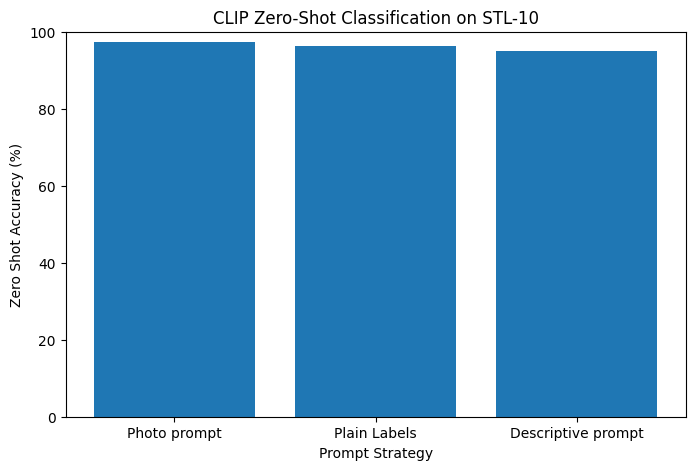

In [15]:
plot.figure(figsize= (8,5))

plot.bar(result_table["Prompt Strategy"], result_table["Accuracy (%)"])
plot.xlabel("Prompt Strategy")
plot.ylabel("Zero Shot Accuracy (%)")
plot.title("CLIP Zero-Shot Classification on STL-10")
plot.ylim(0, 100)

plot.show()

In [16]:
best_strategy = max(results, key = results.get)

best_accuracy = results[best_strategy]

print("Best prompting strategy:", best_strategy)
print("Best Accuracy: " f"{best_accuracy:.2f}%")

Best prompting strategy: Photo prompt
Best Accuracy: 97.36%


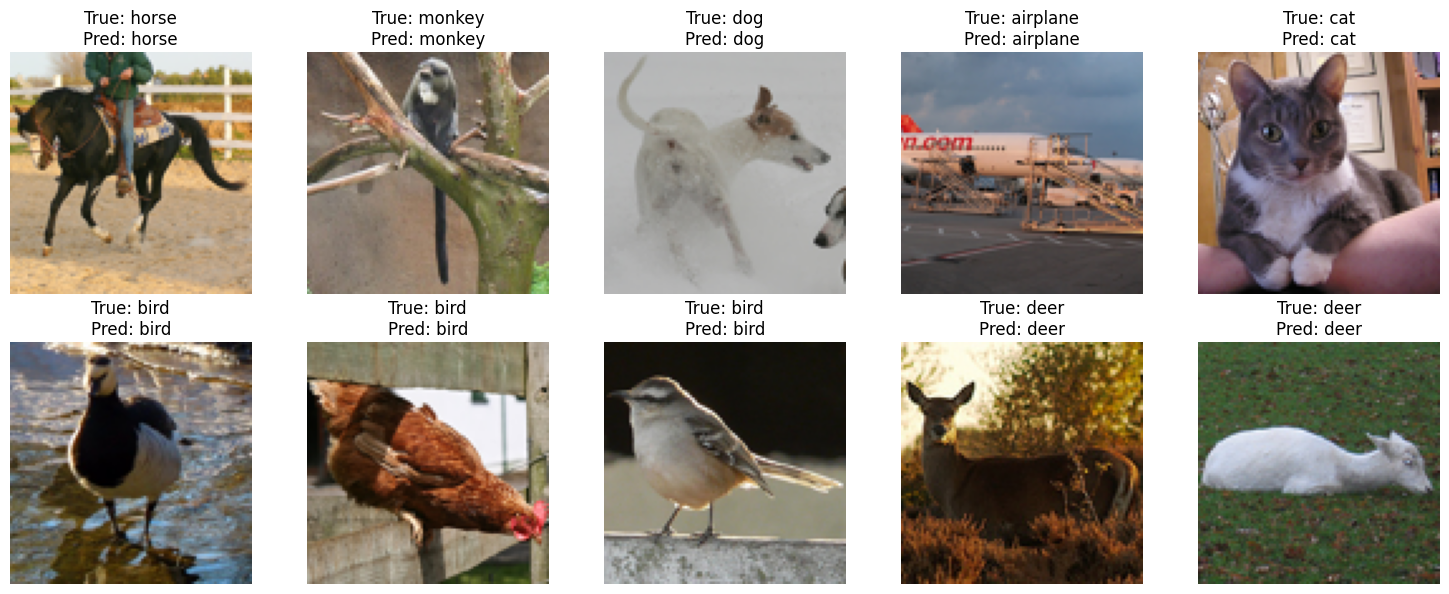

In [17]:
best_predictions = predictions_by_strategy[best_strategy]

figure, axes = plot.subplots(2,5, figsize = (15, 6))

axes = axes.flatten()

for index in range(10):
    image = test_dataset.data[index]

    image = np.transpose(image, (1,2,0))

    true_label = class_names[all_labels[index].item()]

    predicted_label = class_names[best_predictions[index].item()]

    axes[index].imshow(image)
    axes[index].set_title(f"True: {true_label}\n" f"Pred: {predicted_label}")
    axes[index].axis("off")

plot.tight_layout()
plot.show()

# Subtask 2: Exploring the Modality Gap

In this subtask, we investigate whether CLIP's image and text embeddings
occupy the same regions of the shared embedding space.

We:

1. Select 100 balanced STL-10 samples.
2. Extract image embeddings.
3. Extract the corresponding text-label embeddings.
4. Compare embeddings before and after L2 normalization.
5. Use t-SNE to project the 512-dimensional embeddings into 2 dimensions.
6. Visualize and analyze the image-text modality gap.

In [18]:
from sklearn.manifold import TSNE

In [19]:
SAMPLES_PER_CLASS = 10

selected_indices = []

for class_index in range(len(class_names)):

    class_indices = np.where(test_dataset.labels == class_index)[0]

    selected_class_indices = class_indices[:SAMPLES_PER_CLASS]

    selected_indices.extend(selected_class_indices.tolist())

print("Total selected samples:", len(selected_indices))

Total selected samples: 100


In [20]:
selected_labels = test_dataset.labels[selected_indices]

for class_index, class_name in enumerate(class_names):

    count = np.sum(selected_labels == class_index)

    print(f"{class_name:10s}: {count}")

airplane  : 10
bird      : 10
car       : 10
cat       : 10
deer      : 10
dog       : 10
horse     : 10
monkey    : 10
ship      : 10
truck     : 10


In [21]:
sample_images = []
sample_labels = []

for index in selected_indices:

    image, label = test_dataset[index]

    sample_images.append(image)
    sample_labels.append(label)

sample_images = torch.stack(sample_images)

sample_labels = torch.tensor(sample_labels)

print("Sample image shape:", sample_images.shape)

print("Sample label shape:", sample_labels.shape)

Sample image shape: torch.Size([100, 3, 224, 224])
Sample label shape: torch.Size([100])


In [22]:
with torch.inference_mode():
    raw_image_features = model.encode_image(sample_images.to(device))

raw_image_features = (raw_image_features.float().cpu())

print("Raw image feature shape:", raw_image_features.shape)

Raw image feature shape: torch.Size([100, 512])


In [23]:
sample_text_prompts = [photo_prompts[label] for label in sample_labels.tolist()]

print("Number of text prompts:", len(sample_text_prompts))

for index in range(10):
    print(class_names[sample_labels[index].item()], "->", sample_text_prompts[index])

Number of text prompts: 100
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane
airplane -> a photo of a airplane


In [24]:
sample_text_tokens = clip.tokenize(sample_text_prompts).to(device)

with torch.inference_mode():
    raw_text_features = model.encode_text(sample_text_tokens)

raw_text_features = (raw_text_features.float().cpu())

print("Raw text feature shape:", raw_text_features.shape)

Raw text feature shape: torch.Size([100, 512])


In [25]:
raw_image_norms = raw_image_features.norm(dim=1)

raw_text_norms = raw_text_features.norm(dim=1)

print("Average raw image embedding norm:", raw_image_norms.mean().item())
print("Average raw text embedding norm:", raw_text_norms.mean().item())

print("Image norm range:", raw_image_norms.min().item(), "to", raw_image_norms.max().item())
print("Text norm range:", raw_text_norms.min().item(), "to", raw_text_norms.max().item())

Average raw image embedding norm: 10.570115089416504
Average raw text embedding norm: 10.169816017150879
Image norm range: 9.32132339477539 to 11.511815071105957
Text norm range: 9.523733139038086 to 10.701944351196289


In [26]:
normalized_image_features = (raw_image_features / raw_image_features.norm(dim=1, keepdim=True))

normalized_text_features = (raw_text_features / raw_text_features.norm(dim=1, keepdim=True))

In [27]:
normalized_image_norms = (normalized_image_features.norm(dim=1))
normalized_text_norms = (normalized_text_features.norm(dim=1))

print("Average normalized image norm:", normalized_image_norms.mean().item())
print("Average normalized text norm:", normalized_text_norms.mean().item())

Average normalized image norm: 1.0
Average normalized text norm: 1.0


In [28]:
combined_raw_features = torch.cat([raw_image_features, raw_text_features], dim=0)

print("Combined raw feature shape:", combined_raw_features.shape)

Combined raw feature shape: torch.Size([200, 512])


In [29]:
raw_tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")

raw_embedding_2d = raw_tsne.fit_transform(combined_raw_features.numpy())

print("Raw t-SNE shape:", raw_embedding_2d.shape)

Raw t-SNE shape: (200, 2)


In [30]:
raw_image_2d = raw_embedding_2d[:len(selected_indices)]

raw_text_2d = raw_embedding_2d[len(selected_indices):]

print(raw_image_2d.shape, raw_text_2d.shape)

(100, 2) (100, 2)


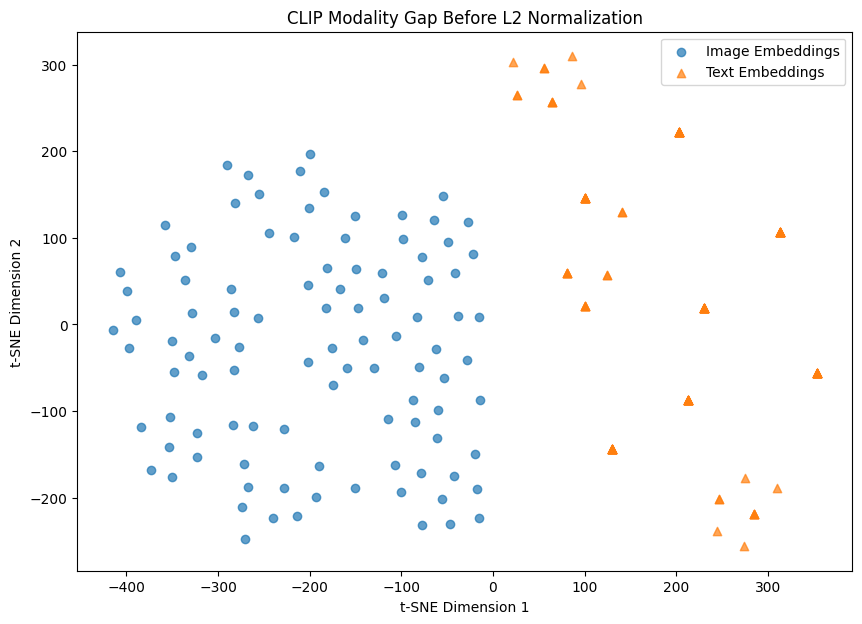

In [31]:
plot.figure(figsize=(10, 7))

plot.scatter(raw_image_2d[:, 0], raw_image_2d[:, 1], marker="o", alpha=0.7, label="Image Embeddings")
plot.scatter(raw_text_2d[:, 0], raw_text_2d[:, 1], marker="^", alpha=0.7, label="Text Embeddings")
plot.xlabel("t-SNE Dimension 1")
plot.ylabel("t-SNE Dimension 2")
plot.title("CLIP Modality Gap Before L2 Normalization")
plot.legend()

plot.show()

In [32]:
combined_normalized_features = torch.cat([normalized_image_features, normalized_text_features], dim=0)

print("Combined normalized feature shape:", combined_normalized_features.shape)

Combined normalized feature shape: torch.Size([200, 512])


In [33]:
normalized_tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")

normalized_embedding_2d = (normalized_tsne.fit_transform(combined_normalized_features.numpy()))

print("Normalized t-SNE shape:", normalized_embedding_2d.shape)

Normalized t-SNE shape: (200, 2)


In [34]:
normalized_image_2d = (normalized_embedding_2d[:len(selected_indices)])

normalized_text_2d = (normalized_embedding_2d[len(selected_indices):])

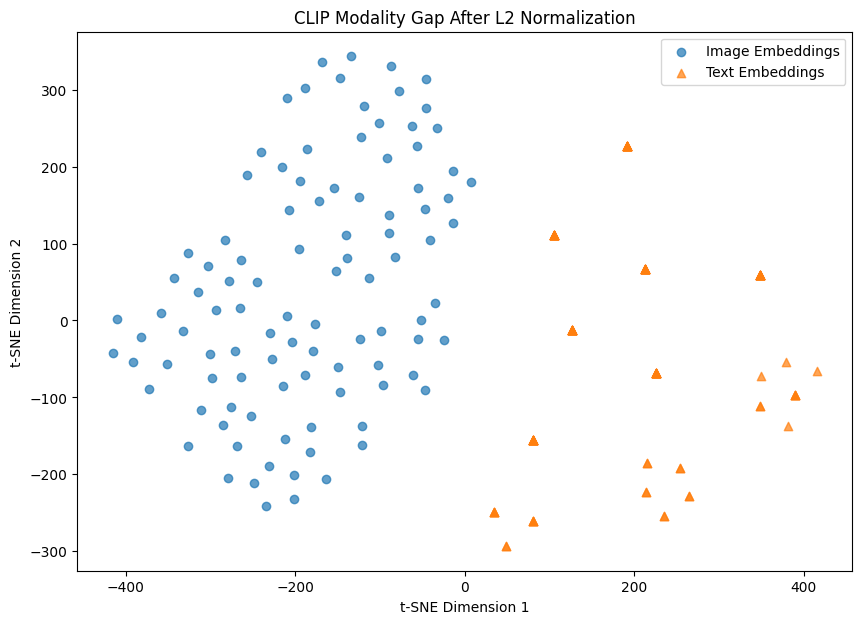

In [35]:
plot.figure(figsize=(10, 7))

plot.scatter(normalized_image_2d[:, 0], normalized_image_2d[:, 1], marker="o", alpha=0.7, label="Image Embeddings")
plot.scatter(normalized_text_2d[:, 0], normalized_text_2d[:, 1], marker="^", alpha=0.7, label="Text Embeddings")
plot.xlabel("t-SNE Dimension 1")
plot.ylabel("t-SNE Dimension 2")
plot.title("CLIP Modality Gap After L2 Normalization")
plot.legend()

plot.show()

In [36]:
raw_image_centroid = (raw_image_features.mean(dim=0))

raw_text_centroid = (raw_text_features.mean(dim=0))

raw_centroid_gap = torch.norm(raw_image_centroid - raw_text_centroid).item()

print("Raw centroid distance:", raw_centroid_gap)

Raw centroid distance: 10.79409122467041


In [37]:
normalized_image_centroid = (normalized_image_features.mean(dim=0))

normalized_text_centroid = (normalized_text_features.mean(dim=0))

normalized_centroid_gap = torch.norm(normalized_image_centroid - normalized_text_centroid).item()

print("Normalized centroid distance:", normalized_centroid_gap)

Normalized centroid distance: 1.044123888015747


In [38]:
paired_cosine_similarities = (normalized_image_features * normalized_text_features).sum(dim=1)

print("Average matching image-text cosine similarity:", paired_cosine_similarities.mean().item())

print("Minimum matching similarity:", paired_cosine_similarities.min().item())

print("Maximum matching similarity:", paired_cosine_similarities.max().item())

Average matching image-text cosine similarity: 0.2662729024887085
Minimum matching similarity: 0.21223141252994537
Maximum matching similarity: 0.311000257730484


In [39]:
unique_text_features = encode_text_prompts(photo_prompts)

sample_class_similarities = (normalized_image_features @ unique_text_features.T)

correct_class_similarities = (sample_class_similarities[torch.arange(len(sample_labels)), sample_labels])

incorrect_class_mask = torch.ones_like(sample_class_similarities, dtype=torch.bool)

incorrect_class_mask[torch.arange(len(sample_labels)), sample_labels] = False

incorrect_class_similarities = (sample_class_similarities[incorrect_class_mask])

print("Average similarity with correct class:", correct_class_similarities.mean().item())

print("Average similarity with incorrect classes:", incorrect_class_similarities.mean().item())

Average similarity with correct class: 0.2662729024887085
Average similarity with incorrect classes: 0.19338996708393097


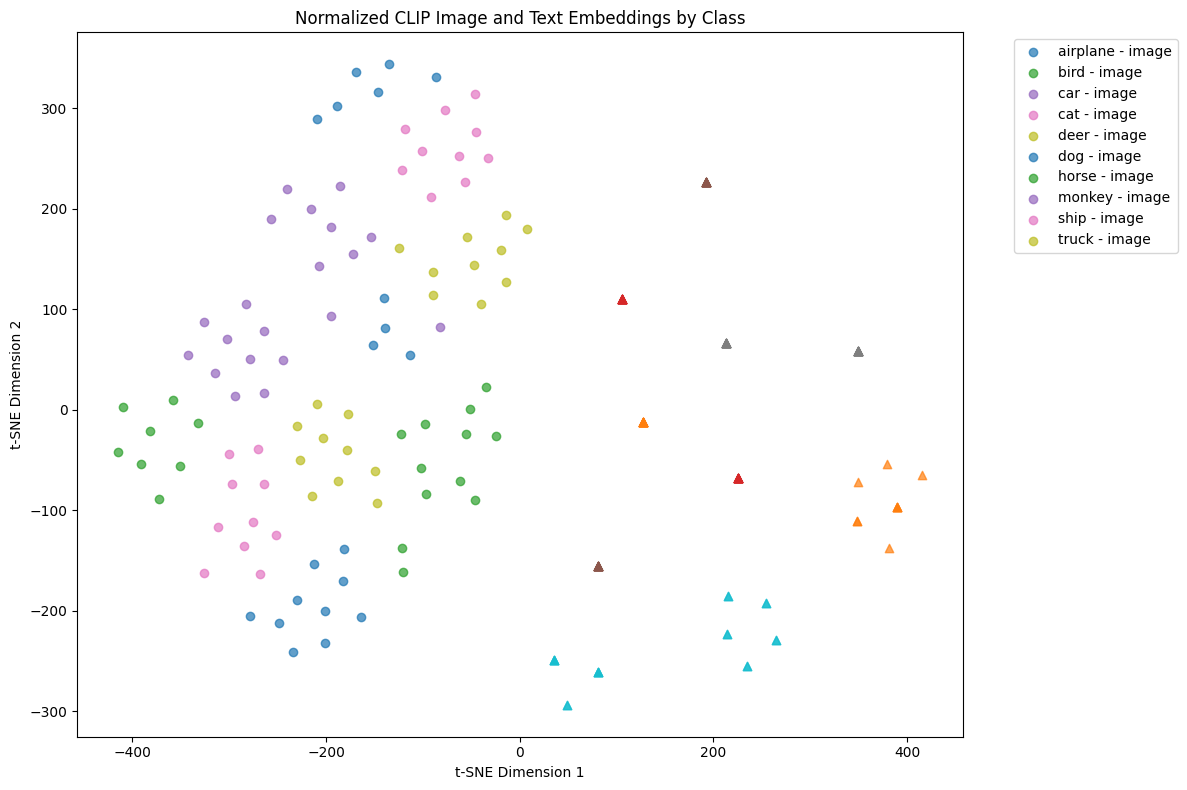

In [40]:
plot.figure(figsize=(12, 8))

for class_index, class_name in enumerate(class_names):

    class_mask = (sample_labels.numpy() == class_index)

    plot.scatter(normalized_image_2d[class_mask,0],
                 normalized_image_2d[class_mask,1],
                 marker="o", alpha=0.7, label=f"{class_name} - image"
                )

    plot.scatter(
                  normalized_text_2d[class_mask,0],
                  normalized_text_2d[class_mask,1],
                  marker="^", alpha=0.7
                )

plot.xlabel("t-SNE Dimension 1")
plot.ylabel("t-SNE Dimension 2")
plot.title("Normalized CLIP Image and Text Embeddings by Class")
plot.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plot.tight_layout()

plot.show()

In [41]:
modality_gap_summary = pd.DataFrame(
        {
            "Metric": [
                "Average Raw Image Norm",
                "Average Raw Text Norm",
                "Raw Centroid Distance",
                "Normalized Centroid Distance",
                "Average Correct-Class Cosine Similarity",
                "Average Incorrect-Class Cosine Similarity"
            ],

            "Value": [
                raw_image_norms.mean().item(),
                raw_text_norms.mean().item(),
                raw_centroid_gap,
                normalized_centroid_gap,
                correct_class_similarities.mean().item(),
                incorrect_class_similarities.mean().item()
            ]
        }
    )

modality_gap_summary

,Metric,Value
0,Average Raw Image Norm,10.570115
1,Average Raw Text Norm,10.169816
2,Raw Centroid Distance,10.794091
3,Normalized Centroid Distance,1.044124
4,Average Correct-Class Cosine Similarity,0.266273
5,Average Incorrect-Class Cosine Similarity,0.193390


# SubTask 2 Analysis

# Subtask 3: Bridging the Modality Gap


In [42]:
from scipy.linalg import orthogonal_procrustes

In [43]:
X = normalized_image_features.numpy()
Y = normalized_text_features.numpy()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (100, 512)
Y shape: (100, 512)


In [44]:
before_alignment_error = np.linalg.norm(X - Y, ord="fro")

print("Frobenius alignment error before Procrustes:", before_alignment_error)

Frobenius alignment error before Procrustes: 12.1138525


In [45]:
rotation_matrix, procrustes_scale = (orthogonal_procrustes(X,Y))

print("Rotation matrix shape:", rotation_matrix.shape)

print("Procrustes scale value:", procrustes_scale)

Rotation matrix shape: (512, 512)
Procrustes scale value: 87.11805


In [46]:
rotation_tensor = torch.tensor(rotation_matrix, dtype=torch.float32)

identity_matrix = torch.eye(rotation_tensor.shape[0])

orthogonality_error = (rotation_tensor.T @ rotation_tensor - identity_matrix).abs().max().item()

print("Maximum orthogonality error:", orthogonality_error)

Maximum orthogonality error: 1.3709068298339844e-06


In [47]:
aligned_image_features = (normalized_image_features @ rotation_tensor)

print("Aligned image feature shape:", aligned_image_features.shape)

Aligned image feature shape: torch.Size([100, 512])


In [48]:
aligned_image_norms = (aligned_image_features.norm(dim=1))

print("Average image norm before alignment:", normalized_image_features.norm(dim=1).mean().item())

print("Average image norm after alignment:", aligned_image_norms.mean().item())

Average image norm before alignment: 1.0
Average image norm after alignment: 1.0


In [49]:
after_alignment_error = np.linalg.norm(aligned_image_features.numpy() - Y, ord="fro")

print("Alignment error before:", before_alignment_error)

print("Alignment error after:", after_alignment_error)

Alignment error before: 12.1138525
Alignment error after: 5.076308


In [50]:
alignment_improvement = ((before_alignment_error - after_alignment_error) / before_alignment_error) * 100

print(f"Reduction in alignment error: " f"{alignment_improvement:.2f}%")

Reduction in alignment error: 58.10%


In [51]:
before_paired_similarity = (normalized_image_features * normalized_text_features).sum(dim=1)

after_paired_similarity = (aligned_image_features * normalized_text_features).sum(dim=1)

print("Average paired cosine similarity before:", before_paired_similarity.mean().item())

print("Average paired cosine similarity after:", after_paired_similarity.mean().item())

Average paired cosine similarity before: 0.2662729024887085
Average paired cosine similarity after: 0.8711553812026978


In [52]:
combined_aligned_features = torch.cat([aligned_image_features, normalized_text_features], dim=0)

print("Combined aligned feature shape:", combined_aligned_features.shape)

Combined aligned feature shape: torch.Size([200, 512])


In [53]:
aligned_tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")

aligned_embedding_2d = (aligned_tsne.fit_transform(combined_aligned_features.numpy()))

print("Aligned t-SNE shape:", aligned_embedding_2d.shape)

Aligned t-SNE shape: (200, 2)


In [54]:
aligned_image_2d = (aligned_embedding_2d[:len(selected_indices)])

aligned_text_2d = (aligned_embedding_2d[len(selected_indices):])

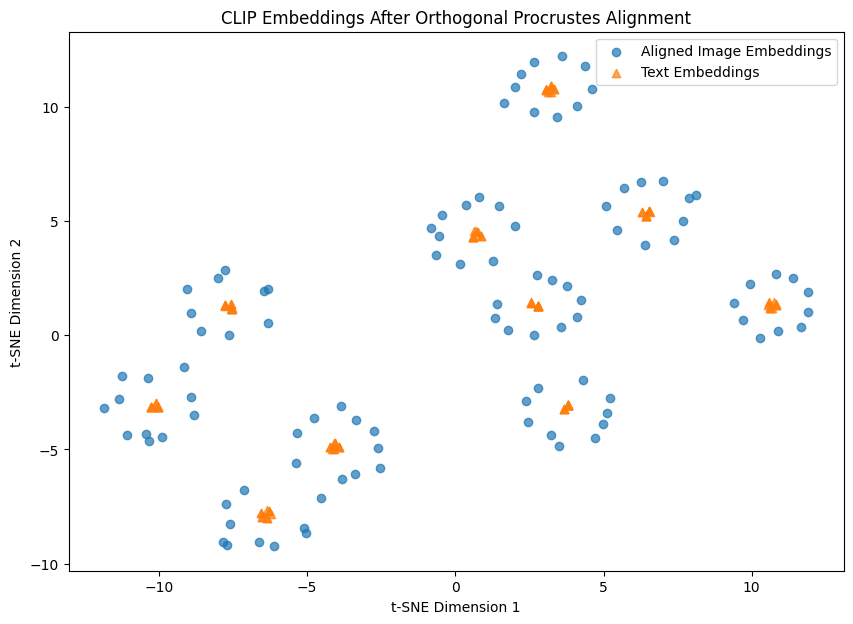

In [55]:
plot.figure(figsize=(10, 7))

plot.scatter(
                aligned_image_2d[:, 0],
                aligned_image_2d[:, 1],
                marker="o", alpha=0.7, label="Aligned Image Embeddings"
            )

plot.scatter(
                aligned_text_2d[:, 0],
                aligned_text_2d[:, 1],
                marker="^", alpha=0.7, label="Text Embeddings"
            )

plot.xlabel("t-SNE Dimension 1")
plot.ylabel("t-SNE Dimension 2")
plot.title("CLIP Embeddings After Orthogonal Procrustes Alignment")
plot.legend()

plot.show()

In [56]:
comparison_features = torch.cat(
        [
            normalized_image_features,
            aligned_image_features,
            normalized_text_features
        ], dim=0
    )

comparison_tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca", learning_rate="auto")

comparison_embedding_2d = (comparison_tsne.fit_transform(comparison_features.numpy()))

In [57]:
N = len(selected_indices)

original_image_comparison_2d = (comparison_embedding_2d[:N])

aligned_image_comparison_2d = (comparison_embedding_2d[N:2 * N])

text_comparison_2d = (comparison_embedding_2d[2 * N:])

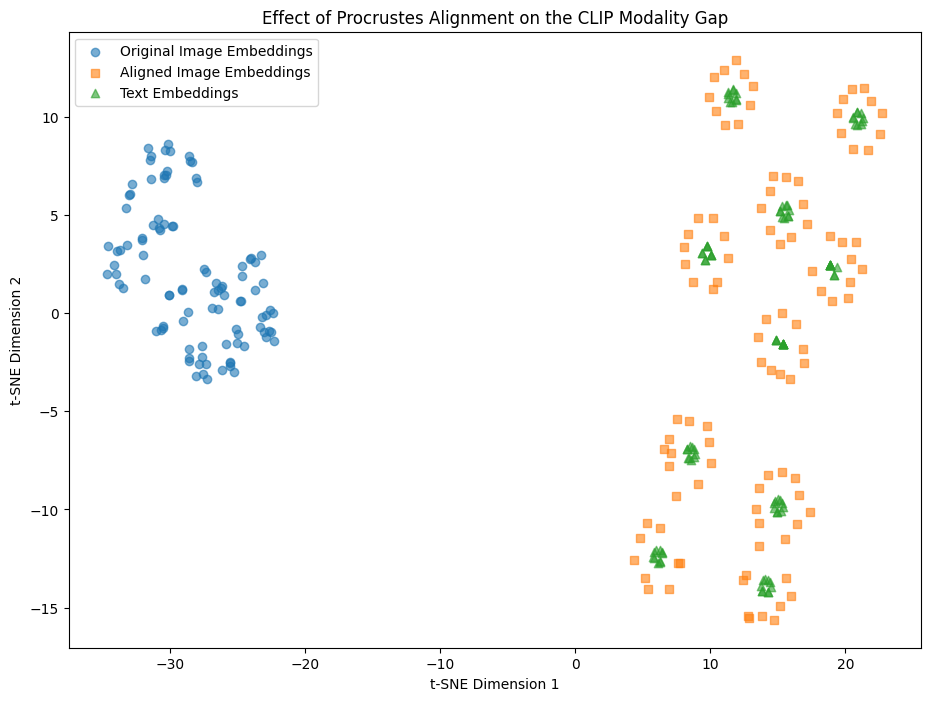

In [58]:
plot.figure(figsize=(11, 8))

plot.scatter(
                original_image_comparison_2d[:, 0],
                original_image_comparison_2d[:, 1],
                marker="o", alpha=0.6, label="Original Image Embeddings"
            )

plot.scatter(
                aligned_image_comparison_2d[:, 0],
                aligned_image_comparison_2d[:, 1],
                marker="s", alpha=0.6, label="Aligned Image Embeddings"
            )

plot.scatter(
                text_comparison_2d[:, 0],
                text_comparison_2d[:, 1],
                marker="^", alpha=0.6, label="Text Embeddings"
            )

plot.xlabel("t-SNE Dimension 1")
plot.ylabel("t-SNE Dimension 2")
plot.title("Effect of Procrustes Alignment on the CLIP Modality Gap")
plot.legend()

plot.show()

In [59]:
full_image_features = (all_image_features.float())

aligned_all_image_features = (full_image_features @ rotation_tensor)

aligned_all_image_features = (aligned_all_image_features / aligned_all_image_features.norm(dim=1, keepdim=True))

print("Aligned full test feature shape:", aligned_all_image_features.shape)

Aligned full test feature shape: torch.Size([8000, 512])


In [60]:
aligned_results = {}

for strategy_name, prompts in (prompt_strategies.items()):

    text_features = encode_text_prompts(prompts).float()

    aligned_accuracy, _ = (calculate_zero_shot_accuracy(aligned_all_image_features, all_labels, text_features))

    aligned_results[strategy_name] = aligned_accuracy

    print(f"{strategy_name}: {aligned_accuracy:.2f}%")

Plain Labels: 96.75%
Photo prompt: 97.65%
Descriptive prompt: 89.35%


In [61]:
alignment_accuracy_table = pd.DataFrame(
    {
        "Prompt Strategy": list(results.keys()),
        "Before Alignment (%)": [results[strategy] for strategy in results],
        "After Alignment (%)": [aligned_results[strategy] for strategy in results]
    }
)

alignment_accuracy_table["Change (%)"] = (
    alignment_accuracy_table["After Alignment (%)"] -
    alignment_accuracy_table["Before Alignment (%)"]
)

alignment_accuracy_table

,Prompt Strategy,Before Alignment (%),After Alignment (%),Change (%)
0,Plain Labels,96.249998,96.749997,0.500000
1,Photo prompt,97.362500,97.649997,0.287497
2,Descriptive prompt,94.962502,89.349997,-5.612504


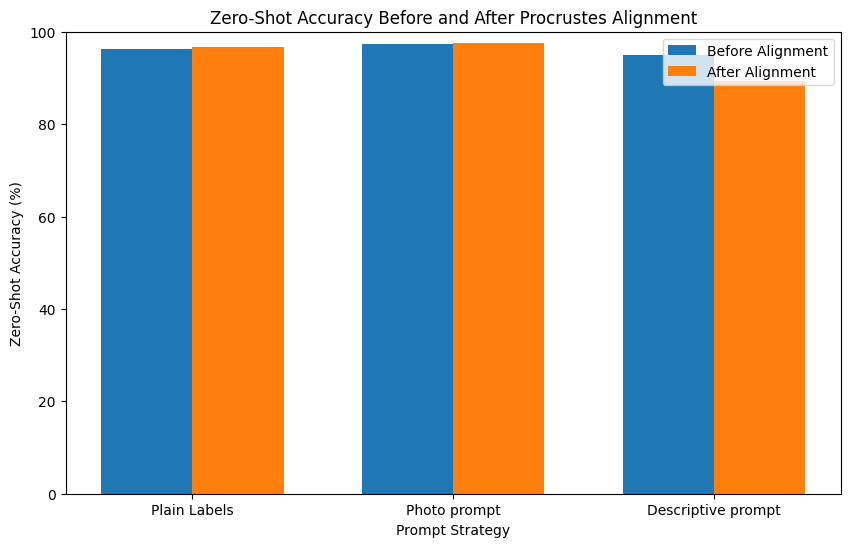

In [62]:
strategies = alignment_accuracy_table["Prompt Strategy"]

before_values = alignment_accuracy_table["Before Alignment (%)"]

after_values = alignment_accuracy_table["After Alignment (%)"]

x = np.arange(len(strategies))
width = 0.35

plot.figure(figsize=(10, 6))

plot.bar(x - width / 2, before_values, width, label="Before Alignment")
plot.bar(x + width / 2, after_values, width, label="After Alignment")

plot.xticks(x, strategies)
plot.xlabel("Prompt Strategy")
plot.ylabel("Zero-Shot Accuracy (%)")
plot.title("Zero-Shot Accuracy Before and After Procrustes Alignment")
plot.ylim(0,100)

plot.legend()
plot.show()

In [63]:
alignment_summary = pd.DataFrame(
    {
        "Metric":
        [
            "Frobenius Error Before Alignment",
            "Frobenius Error After Alignment",
            "Alignment Error Reduction (%)",
            "Average Paired Cosine Similarity Before",
            "Average Paired Cosine Similarity After"
        ],

        "Value":
        [
            before_alignment_error,
            after_alignment_error,
            alignment_improvement,
            before_paired_similarity.mean().item(),
            after_paired_similarity.mean().item()
        ]
    }
)

alignment_summary

,Metric,Value
0,Frobenius Error Before Alignment,12.113853
1,Frobenius Error After Alignment,5.076308
2,Alignment Error Reduction (%),58.095020
3,Average Paired Cosine Similarity Before,0.266273
4,Average Paired Cosine Similarity After,0.871155


In [64]:
best_baseline_strategy = max(results, key=results.get)

best_aligned_strategy = max(aligned_results, key=aligned_results.get)

print("Best baseline strategy:", best_baseline_strategy)
print("Best baseline accuracy: " f"{results[best_baseline_strategy]:.2f}%")

print()

print("Best aligned strategy:", best_aligned_strategy)

print("Best aligned accuracy: " f"{aligned_results[best_aligned_strategy]:.2f}%")

Best baseline strategy: Photo prompt
Best baseline accuracy: 97.36%

Best aligned strategy: Photo prompt
Best aligned accuracy: 97.65%
